**Check the patterns of load and feedrate per CR**

### Libraries: 

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from dtw import dtw
import copy

from keras.models import Sequential
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout

import plotly.express as px

### Load Data: 

In [ ]:
eda_data = pd.read_pickle('../data/inlier_data.pkl')
eda_data.head() 

### Train-Test Split: 

In [27]:
df10_cr_set = list(df10_cr_set)
size = len(df10_cr_set)

train_ratio = 0.8
train_size = int(size*train_ratio)
test_size = size - train_size

print('train_size: ', train_size)
print('test_size: ', test_size)

train_crs = df10_cr_set[0: train_size]
test_crs = df10_cr_set[train_size: -1]

print('train_crs: ', train_crs)
print('test_crs: ', test_crs)

train_size:  9
test_size:  3
train_crs:  [2, 4, 5, 6, 7, 8, 9, 11, 12]
test_crs:  [13, 15]


## EDA

In [ ]:
# eda_data = dfN10_load_filtered_cr.copy()

#### Plotting original data on CR-level to see load and feed pattern per CR:  

In [29]:
# Inlier data: dfN10_load_filtered_cr
eda_data.head()

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution,program_name,nsequence,cr,index,load_Rotary_C5_temp,cr_numeric
0,2024-03-11 15:40:47.167578,2.0,18.886,10.1493,35.0,239.27,0,O0005(5303-005-C),N10,CR-2,0,0.014493,2
1,2024-03-11 15:40:56.190506,1.0,18.886,10.1493,35.0,239.27,0,O0005(5303-005-C),N10,CR-2,1,0.000000,2
2,2024-03-11 15:41:01.202792,1.0,16.250,3.9771,35.0,239.25,0,O0005(5303-005-C),N10,CR-2,2,0.000000,2
3,2024-03-11 15:42:17.411486,2.0,16.250,0.8980,35.0,10.78,0,O0005(5303-005-C),N10,CR-2,3,0.014493,2
4,2024-03-11 15:42:22.424109,1.0,16.250,0.8980,35.0,10.78,0,O0005(5303-005-C),N10,CR-2,4,0.000000,2


In [30]:
fig = px.line(
    eda_data, 
    x="index", 
    y="load_Rotary_C5", 
    color='cr', 
)
fig.show()

In [31]:
fig = px.line(
    eda_data, 
    x='index', 
    y='pathfeedrate_Path_Path_1', 
    color='cr'
)
fig.show()

#### Checking load and feed distributions: 

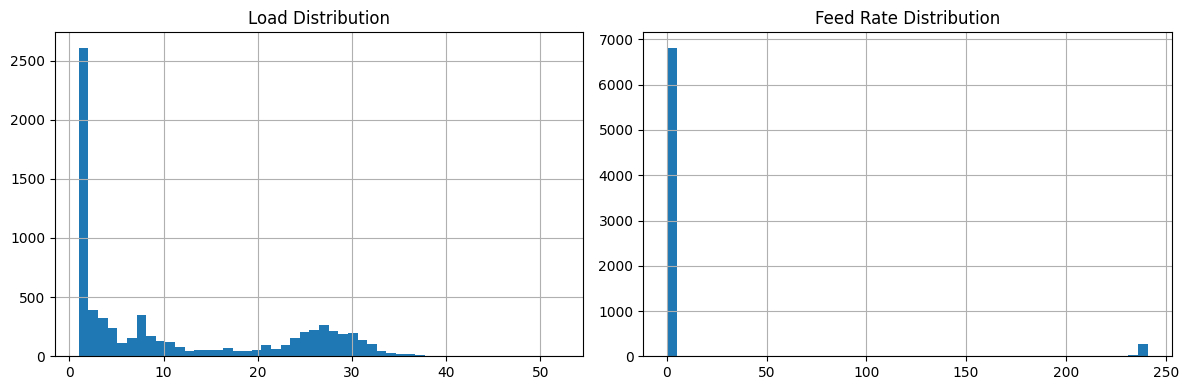

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

eda_data['load_Rotary_C5'].hist(bins=50, ax=ax[0])
ax[0].set_title('Load Distribution')

eda_data['pathfeedrate_Path_Path_1'].hist(bins=50, ax=ax[1])
ax[1].set_title('Feed Rate Distribution')

plt.tight_layout()
plt.show()

In [34]:
print(
    eda_data[['load_Rotary_C5', 'pathfeedrate_Path_Path_1']]
    .corr()
)

                          load_Rotary_C5  pathfeedrate_Path_Path_1
load_Rotary_C5                  1.000000                 -0.186151
pathfeedrate_Path_Path_1       -0.186151                  1.000000


In [38]:
group_corrs = (
    eda_data.groupby('cr')
      .apply(
          lambda g:
          g['load_Rotary_C5'].corr(g['pathfeedrate_Path_Path_1'])
      )
)

group_corrs

cr
CR-11   -0.171183
CR-12   -0.169546
CR-13   -0.162454
CR-15   -0.214314
CR-16   -0.234684
CR-2    -0.115818
CR-4    -0.162669
CR-5    -0.211390
CR-6    -0.214085
CR-7    -0.234174
CR-8    -0.203599
CR-9    -0.210322
dtype: float64

In [41]:
def autocorr_at_lag(series, lag):
    return series.autocorr(lag)

results = []

for gid, grp in eda_data.groupby('cr'):

    results.append({
        'cr': gid,
        'lag5_corr': grp['load_Rotary_C5'].autocorr(5),
        'lag10_corr': grp['load_Rotary_C5'].autocorr(10),
        'lag20_corr': grp['load_Rotary_C5'].autocorr(20),
        'lag50_corr': grp['load_Rotary_C5'].autocorr(50)
    })

acf_df = pd.DataFrame(results)
acf_df

,cr,lag5_corr,lag10_corr,lag20_corr,lag50_corr
0,CR-11,0.796642,0.762903,0.582502,0.196044
1,CR-12,0.780991,0.782133,0.595981,0.268820
2,CR-13,0.908457,0.831598,0.663662,0.331320
3,CR-15,0.865101,0.769544,0.594124,0.133009
4,CR-16,0.822000,0.708293,0.535186,0.066928
5,CR-2,0.754380,0.746495,0.583251,0.161540
6,CR-4,0.922163,0.842578,0.670341,0.323409
7,CR-5,0.910198,0.812994,0.606792,0.128674
8,CR-6,0.852236,0.769167,0.599372,0.165248
9,CR-7,0.814041,0.719176,0.536262,0.067867
